# Notebook 07: 3D Mollweide CMB Map / 3D全天图 (Fig 1a)

**对应论文 Figure 1(a)** — 3D 辛格宇宙学全天 CMB 图

生成 128^3 初始场 (P(k)~k^{-1.5}, std=0.15)，演化 60 步 (c2=0.45, c0=10, drag=0.01, 无非线性项)，
投影到 Mollweide 球面 (400x800 网格, radius=0.35*N)，绘制全天 CMB 图。
同时绘制 3D 宇宙网 (MIP 投影)。

**Expected key result / 预期关键结果:** 视觉上类似真实 CMB 温度涨落图

In [1]:
# ── Imports / 导入 ──
import sys; sys.path.insert(0, '../src')
from dsc_engine import *

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print("Engine loaded / ")

Engine loaded / 


## 1. Generate and evolve 3D field / 生成并演化 3D 场

128^3 格点, P(k) ~ k^{-1.5}, 60 步辛格演化, 无非线性项

In [2]:
# ── 3D simulation parameters / 3D Simulation参数 ──
N3D = 128       # 3D Lattice边长 / 3D grid size
N_STEPS = 60    # 演化Steps / evolution steps
C2 = 0.45       # 声速平方 / sound speed squared
C0 = 10.0       # 正则化偏移 / regularization offset
DRAG = 0.01     # Hubble 阻尼 / Hubble drag
NONLINEAR = 0.0 # 无非线性项 / no nonlinear term

print(f"Generating {N3D}^3 initial field (P(k) ~ k^{{-1.5}}, std=0.15)...")
phi0_3d = generate_initial_3d(N3D, seed=42, spectral_index=0.75)
print(f"  Initial field: mean={phi0_3d.mean():.4f}, std={phi0_3d.std():.4f}")

print(f"Evolving {N_STEPS} steps (c2={C2}, drag={DRAG}, nonlinear={NONLINEAR})...")
phi_3d = evolve_symplectic_3d(phi0_3d, n_steps=N_STEPS, c2_base=C2,
                               c0=C0, drag=DRAG, nonlinear=NONLINEAR)
print(f"  Final field: mean={phi_3d.mean():.4f}, std={phi_3d.std():.4f}")
print("Done / !")

Generating 128^3 initial field (P(k) ~ k^{-1.5}, std=0.15)...


  Initial field: mean=0.0000, std=0.1500
Evolving 60 steps (c2=0.45, drag=0.01, nonlinear=0.0)...


  Final field: mean=-0.0000, std=0.1062
Done / !


## 2. Mollweide projection / Mollweide 球面投影

从 3D 场中心取球壳 (radius=0.35*N)，投影到 (theta, phi) 网格上，
使用 Mollweide 投影绘制全天图。

In [3]:
# ── Sphere sampling / 球面采样 ──
N_theta, N_phi_grid = 400, 800  # Mollweide 网格分辨率
R = 0.35 * N3D                  # 球壳半径 / shell radius
center = N3D / 2.0              # 场中心 / field center

# 生成 (theta, phi) 网格 / generate angular grid
theta = np.linspace(0, np.pi, N_theta)        # 极角 [0, pi]
phi_ang = np.linspace(-np.pi, np.pi, N_phi_grid)  # 方位角 [-pi, pi]
THETA, PHI = np.meshgrid(theta, phi_ang, indexing='ij')

# 球坐标 → 笛卡尔坐标 / spherical to Cartesian
x_sph = center + R * np.sin(THETA) * np.cos(PHI)
y_sph = center + R * np.sin(THETA) * np.sin(PHI)
z_sph = center + R * np.cos(THETA)

# 最近邻插值 / nearest-neighbor interpolation
ix = np.clip(np.round(x_sph).astype(int), 0, N3D - 1)
iy = np.clip(np.round(y_sph).astype(int), 0, N3D - 1)
iz = np.clip(np.round(z_sph).astype(int), 0, N3D - 1)
cmb_map = phi_3d[ix, iy, iz]

# 归一化 / normalize
cmb_map = (cmb_map - cmb_map.mean()) / (cmb_map.std() + 1e-15)
print(f"CMB map shape: {cmb_map.shape}, range: [{cmb_map.min():.2f}, {cmb_map.max():.2f}]")

CMB map shape: (400, 800), range: [-4.02, 4.30]


## 3. Plot full-sky CMB map / 绘制全天 CMB 图 (Fig 1a)

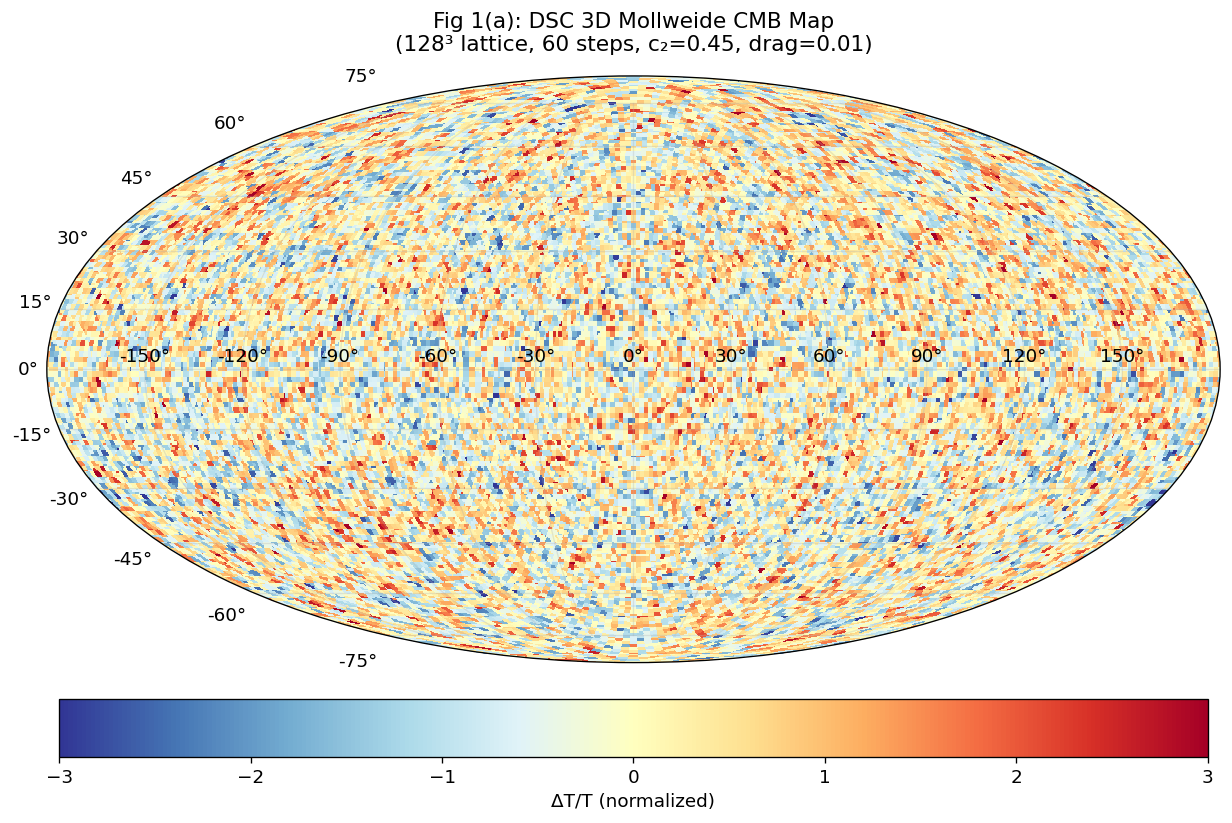

Figure saved to ../figures/fig1a_mollweide_cmb.png


In [4]:
# ── Mollweide CMB plot / Mollweide Full-sky Map ──
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection='mollweide')

# 转换坐标: theta ∈ [0,pi] → lat ∈ [-pi/2, pi/2]
lat = np.pi / 2 - THETA  # latitude = pi/2 - colatitude

vmax = 3.0  # 截断范围 / clipping range
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

im = ax.pcolormesh(PHI, lat, cmb_map, cmap='RdYlBu_r', norm=norm,
                    shading='auto', rasterized=True)
ax.set_title('Fig 1(a): DSC 3D Mollweide CMB Map\n'
             '(128³ lattice, 60 steps, c₂=0.45, drag=0.01)',
             fontsize=13, pad=15)
ax.grid(True, alpha=0.3)
cb = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05,
                   shrink=0.7, label='ΔT/T (normalized)')
plt.tight_layout()
plt.savefig('../figures/fig1a_mollweide_cmb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to ../figures/fig1a_mollweide_cmb.png")

## 4. 3D Cosmic web (MIP projection) / 3D 宇宙网 (最大强度投影)

沿 z 轴做最大强度投影 (Maximum Intensity Projection)，展示 3D 结构。

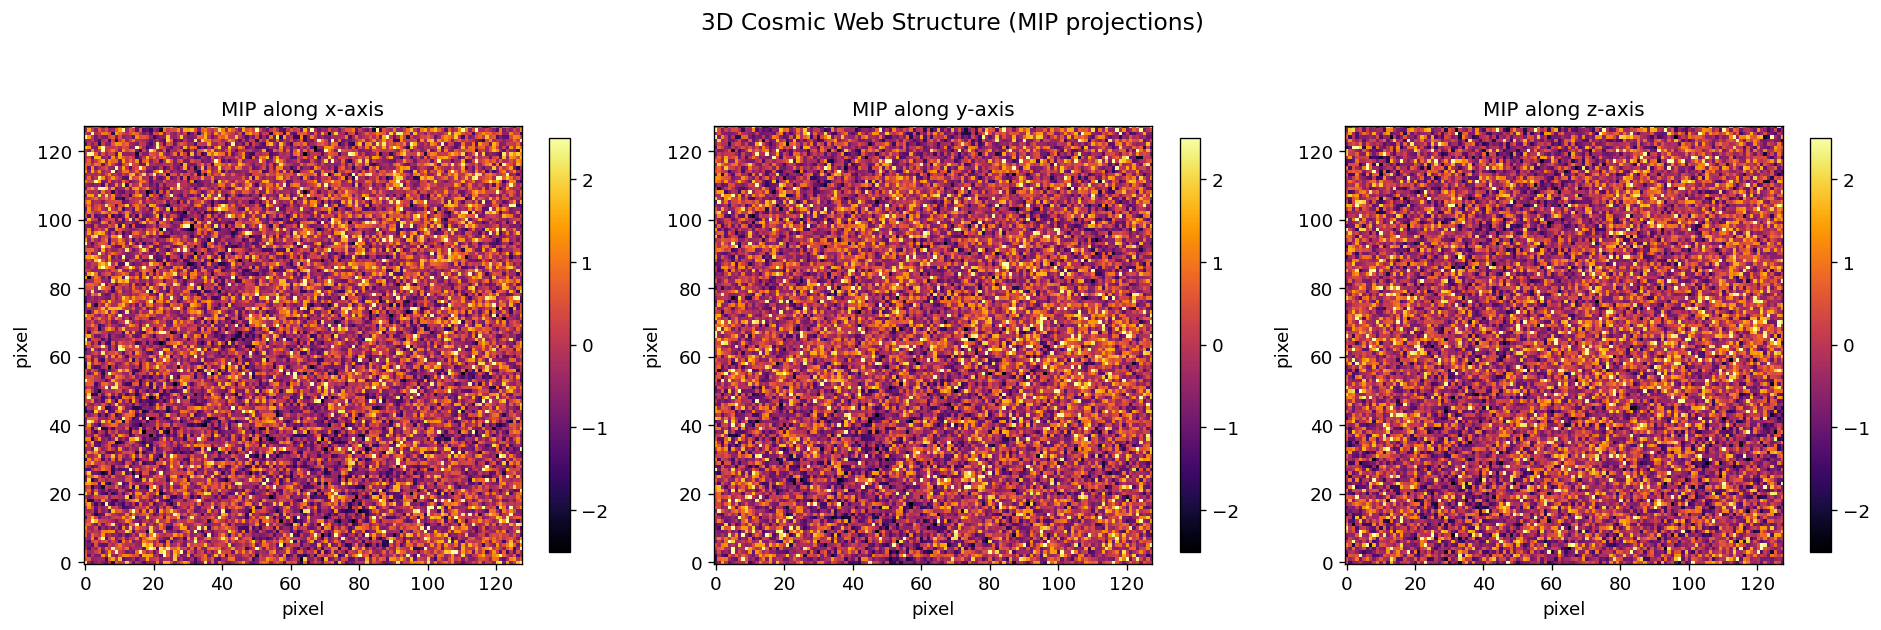

Figure saved to ../figures/fig1a_cosmic_web_mip.png


In [5]:
# ── MIP projection along z-axis / 沿 z 轴最大强度投影 ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (axis, label) in enumerate(zip([0, 1, 2], ['x', 'y', 'z'])):
    mip = phi_3d.max(axis=axis)
    mip_norm = (mip - mip.mean()) / (mip.std() + 1e-15)
    im = axes[i].imshow(mip_norm, cmap='inferno', origin='lower',
                         vmin=-2.5, vmax=2.5)
    axes[i].set_title(f'MIP along {label}-axis', fontsize=12)
    axes[i].set_xlabel('pixel')
    axes[i].set_ylabel('pixel')
    plt.colorbar(im, ax=axes[i], shrink=0.8)

plt.suptitle('3D Cosmic Web Structure (MIP projections)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/fig1a_cosmic_web_mip.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to ../figures/fig1a_cosmic_web_mip.png")